## Consommation annoncée VS consommation réelle

## ⚙️ Régression multiple & Analyse des erreurs

### ➡️ Chargement des librairies et du dataset

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


data = pd.read_csv("Data/fuel_S9.csv")
data = data.dropna(subset=["combined_mpg_ft1", "my_mpg_data"])
data.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_7632\3185567836.py:11: DtypeWarning: Columns (7,44) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Data/fuel_S9.csv")


,vehicle_id,year,make,model,class,drive,transmission,transmission_type,engine_index,engine_descriptor,...,hours_to_charge_ac_240v,composite_city_mpg,composite_highway_mpg,composite_combined_mpg,range_ft1,city_range_ft1,highway_range_ft1,range_ft2,city_range_ft2,highway_range_ft2
0,26587,1984,Alfa Romeo,GT V6 2.5,Minicompact Cars,NaN,Manual 5-Speed,NaN,9001,(FFS),...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0
1,27705,1984,Alfa Romeo,GT V6 2.5,Minicompact Cars,NaN,Manual 5-Speed,NaN,9005,(FFS) CA model,...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0
2,26561,1984,Alfa Romeo,Spider Veloce 2000,Two Seaters,NaN,Manual 5-Speed,NaN,9002,(FFS),...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0
3,27681,1984,Alfa Romeo,Spider Veloce 2000,Two Seaters,NaN,Manual 5-Speed,NaN,9006,(FFS) CA model,...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0
4,27550,1984,AM General,DJ Po Vehicle 2WD,Special Purpose Vehicle 2WD,2-Wheel Drive,Automatic 3-Speed,NaN,1830,(FFS),...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0


### ➡️ Conversion mpg en L/100 km

In [14]:
data = data.dropna(subset=["combined_mpg_ft1", "unrounded_combined_mpg_ft1"])

def mpg_to_l100(mpg):
    return 235.21 / mpg

data["announced_l100"] = mpg_to_l100(data["combined_mpg_ft1"])
data["real_l100"] = mpg_to_l100(data["unrounded_combined_mpg_ft1"])

data["error_l100"] = data["real_l100"] - data["announced_l100"]


data["error_l100"].describe()


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: error_l100, dtype: float64

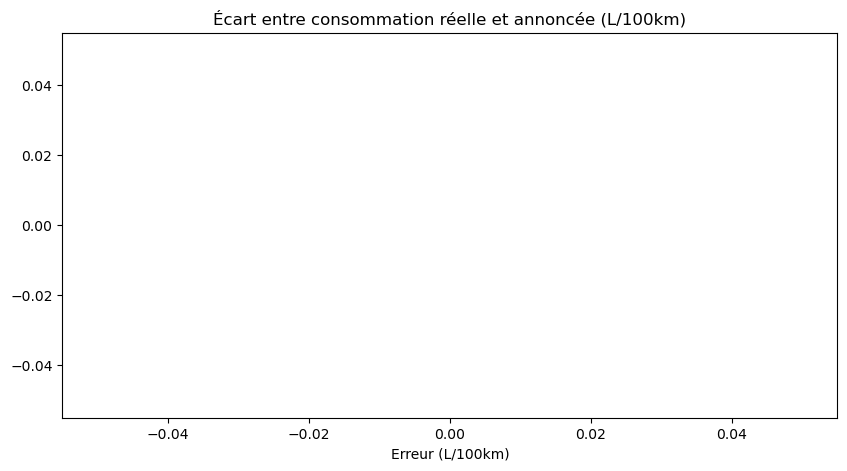

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(data["error_l100"], kde=True)
plt.title("Écart entre consommation réelle et annoncée (L/100km)")
plt.xlabel("Erreur (L/100km)")
plt.show()

In [4]:
# Suppression des lignes incomplètes
data = data.dropna()

# Création de la variable d'écart
data["error"] = data["consumption_real"] - data["consumption_announced"]

data.describe()


KeyError: 'consumption_real'